# 03 — R-Peak Detection

**Purpose:** Detect R-peaks in all 70 records using Pan-Tompkins via neurokit2, compute RR intervals, and perform detection quality control.

**Inputs:** Raw ECG recordings from `data/raw/`; `data/features/record_inventory.csv`

**Outputs:**
- `data/rpeaks/{record_id}_rpeaks.npy` — R-peak sample indices per record
- `reports/figures/rpeak_validation.png` — visual validation of detections

![Status: COMPLETE](https://img.shields.io/badge/Status-COMPLETE-brightgreen)

In [1]:
# ── Cell 1: Imports and paths ─────────────────────────────────────────────────
import pathlib, warnings
import numpy as np
import pandas as pd
import wfdb
import neurokit2 as nk
import matplotlib
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'figure.dpi': 120, 'font.size': 9})

RAW_DIR     = pathlib.Path('../data/raw')
RPEAKS_DIR  = pathlib.Path('../data/rpeaks')
FIGURES_DIR = pathlib.Path('../reports/figures')
RPEAKS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

inventory  = pd.read_csv('../data/features/record_inventory.csv')
record_ids = inventory['record_id'].tolist()
print(f'Records to process: {len(record_ids)}')

Records to process: 70


In [2]:
# ── Cell 2: Helper functions ───────────────────────────────────────────────────
def load_ecg(rec_id):
    """Return (signal_1d_float64, fs) for the first ECG channel."""
    rec = wfdb.rdrecord(str(RAW_DIR / rec_id))
    return rec.p_signal[:, 0].astype(float), rec.fs

def load_annotations(rec_id, fs=100):
    """Return dict {minute_index: symbol} from .apn file, or empty dict."""
    ann_path = RAW_DIR / f'{rec_id}.apn'
    if not ann_path.exists():
        return {}
    ann = wfdb.rdann(str(RAW_DIR / rec_id), extension='apn')
    minute_indices = (ann.sample // (60 * fs)).astype(int)
    return dict(zip(minute_indices, ann.symbol))

In [3]:
# ── Cell 3: R-peak detection — all 70 records ─────────────────────────────────
# Primary method: Pan-Tompkins. If the detected rate is physiologically
# implausible (<40 or >140 peaks/min), retry with neurokit's own algorithm.

detection_results = {}   # rec_id → {'rpeaks': ndarray, 'fs': int, 'method': str, 'error': str|None}
failed = []

for i, rec_id in enumerate(record_ids):
    print(f'  [{i+1:02d}/{len(record_ids)}] {rec_id} ...', end=' ')
    try:
        sig, fs   = load_ecg(rec_id)
        dur_min   = len(sig) / fs / 60

        # --- Primary: Pan-Tompkins ---
        ecg_clean = nk.ecg_clean(sig, sampling_rate=fs, method='pantompkins1985')
        _, info   = nk.ecg_peaks(ecg_clean, sampling_rate=fs, method='pantompkins1985')
        rpeaks    = info['ECG_R_Peaks']
        method    = 'pantompkins1985'

        # --- Fallback: neurokit if rate is implausible ---
        rate = len(rpeaks) / dur_min if dur_min > 0 else 0
        if not (40 <= rate <= 140):
            ecg_clean2 = nk.ecg_clean(sig, sampling_rate=fs, method='neurokit')
            _, info2   = nk.ecg_peaks(ecg_clean2, sampling_rate=fs, method='neurokit')
            rpeaks2    = info2['ECG_R_Peaks']
            rate2      = len(rpeaks2) / dur_min if dur_min > 0 else 0
            if (40 <= rate2 <= 140):
                rpeaks, method = rpeaks2, 'neurokit (fallback)'

        np.save(RPEAKS_DIR / f'{rec_id}_rpeaks.npy', rpeaks)
        detection_results[rec_id] = {'rpeaks': rpeaks, 'fs': fs, 'method': method, 'error': None}
        print(f'{len(rpeaks):,} peaks  [{method}]')

    except Exception as exc:
        failed.append(rec_id)
        detection_results[rec_id] = {'rpeaks': np.array([]), 'fs': 100, 'method': 'none', 'error': str(exc)}
        print(f'FAILED: {str(exc)[:70]}')

print(f'\nDetection complete.  Failed: {len(failed)}')
if failed:
    print(f'  Failed records: {failed}')


  [01/70] a01 ... 29,939 peaks  [pantompkins1985]
  [02/70] a02 ... 42,595 peaks  [pantompkins1985]
  [03/70] a03 ... 34,293 peaks  [neurokit (fallback)]
  [04/70] a04 ... 31,226 peaks  [pantompkins1985]
  [05/70] a05 ... 28,763 peaks  [pantompkins1985]
  [06/70] a06 ... 31,068 peaks  [pantompkins1985]
  [07/70] a07 ... 37,473 peaks  [pantompkins1985]
  [08/70] a08 ... 41,141 peaks  [pantompkins1985]
  [09/70] a09 ... 31,573 peaks  [pantompkins1985]
  [10/70] a10 ... 32,304 peaks  [pantompkins1985]
  [11/70] a11 ... 33,202 peaks  [pantompkins1985]
  [12/70] a12 ... 35,851 peaks  [pantompkins1985]
  [13/70] a13 ... 39,785 peaks  [pantompkins1985]
  [14/70] a14 ... 29,018 peaks  [pantompkins1985]
  [15/70] a15 ... 33,974 peaks  [pantompkins1985]
  [16/70] a16 ... 34,931 peaks  [pantompkins1985]
  [17/70] a17 ... 28,247 peaks  [pantompkins1985]
  [18/70] a18 ... 30,275 peaks  [pantompkins1985]
  [19/70] a19 ... 38,773 peaks  [pantompkins1985]
  [20/70] a20 ... 34,492 peaks  [pantompkins19

In [4]:
# ── Cell 4: Build detection QC DataFrame ──────────────────────────────────────
qc_rows = []

for rec_id in record_ids:
    r       = detection_results[rec_id]
    rpeaks  = r['rpeaks']
    fs      = r['fs']
    dur_min = float(inventory.loc[inventory['record_id'] == rec_id, 'duration_minutes'].iloc[0])

    if len(rpeaks) < 2:
        qc_rows.append({
            'record_id':              rec_id,
            'n_peaks':                len(rpeaks),
            'mean_hr_bpm':            np.nan,
            'min_hr_bpm':             np.nan,
            'max_hr_bpm':             np.nan,
            'detection_rate_per_min': np.nan,
            'method':                 r.get('method', ''),
            'flagged':                True,
            'flag_reason':            r['error'] or 'too few peaks',
        })
        continue

    rr_s = np.diff(rpeaks).astype(float) / fs
    # Clip physiologically implausible intervals before HR computation
    rr_s = rr_s[(rr_s > 0.20) & (rr_s < 3.0)]
    hr   = 60.0 / rr_s if len(rr_s) > 0 else np.array([np.nan])

    mean_hr = float(np.nanmean(hr))
    min_hr  = float(np.nanmin(hr))
    max_hr  = float(np.nanmax(hr))
    rate    = len(rpeaks) / dur_min

    reasons = []
    if not (30 <= mean_hr <= 120):
        reasons.append(f'mean HR {mean_hr:.1f} BPM')
    if not (40 <= rate <= 140):
        reasons.append(f'rate {rate:.1f}/min')

    qc_rows.append({
        'record_id':              rec_id,
        'n_peaks':                len(rpeaks),
        'mean_hr_bpm':            round(mean_hr, 2),
        'min_hr_bpm':             round(min_hr,  2),
        'max_hr_bpm':             round(max_hr,  2),
        'detection_rate_per_min': round(rate,     2),
        'method':                 r.get('method', ''),
        'flagged':                len(reasons) > 0,
        'flag_reason':            '; '.join(reasons),
    })

qc_df = pd.DataFrame(qc_rows)
n_flagged = int(qc_df['flagged'].sum())
print(f'QC complete — flagged: {n_flagged} / {len(qc_df)}')

QC complete — flagged: 0 / 70


In [5]:
# ── Cell 5: Display QC table (flagged rows in red) ────────────────────────────
def _highlight_flagged(row):
    if row.get('flagged', False):
        return ['background-color: #b00020; color: white'] * len(row)
    return [''] * len(row)

(
    qc_df.style
    .apply(_highlight_flagged, axis=1)
    .format({
        'mean_hr_bpm':            '{:.1f}',
        'min_hr_bpm':             '{:.1f}',
        'max_hr_bpm':             '{:.1f}',
        'detection_rate_per_min': '{:.1f}',
    }, na_rep='—')
    .set_caption('R-Peak Detection QC — red rows flagged')
)

,record_id,n_peaks,mean_hr_bpm,min_hr_bpm,max_hr_bpm,detection_rate_per_min,method,flagged,flag_reason
0,a01,29939,62.5,32.8,146.3,60.8,pantompkins1985,False,
1,a02,42595,81.3,20.6,230.8,80.3,pantompkins1985,False,
2,a03,34293,67.4,27.0,187.5,65.6,neurokit (fallback),False,
3,a04,31226,64.0,22.9,193.6,62.9,pantompkins1985,False,
4,a05,28763,64.0,38.5,193.6,63.5,pantompkins1985,False,
5,a06,31068,61.6,30.1,230.8,61.0,pantompkins1985,False,
6,a07,37473,75.3,23.9,142.9,73.5,pantompkins1985,False,
7,a08,41141,82.9,49.2,136.4,82.2,pantompkins1985,False,
8,a09,31573,63.7,38.2,181.8,63.4,pantompkins1985,False,
9,a10,32304,63.0,35.9,193.6,62.5,pantompkins1985,False,


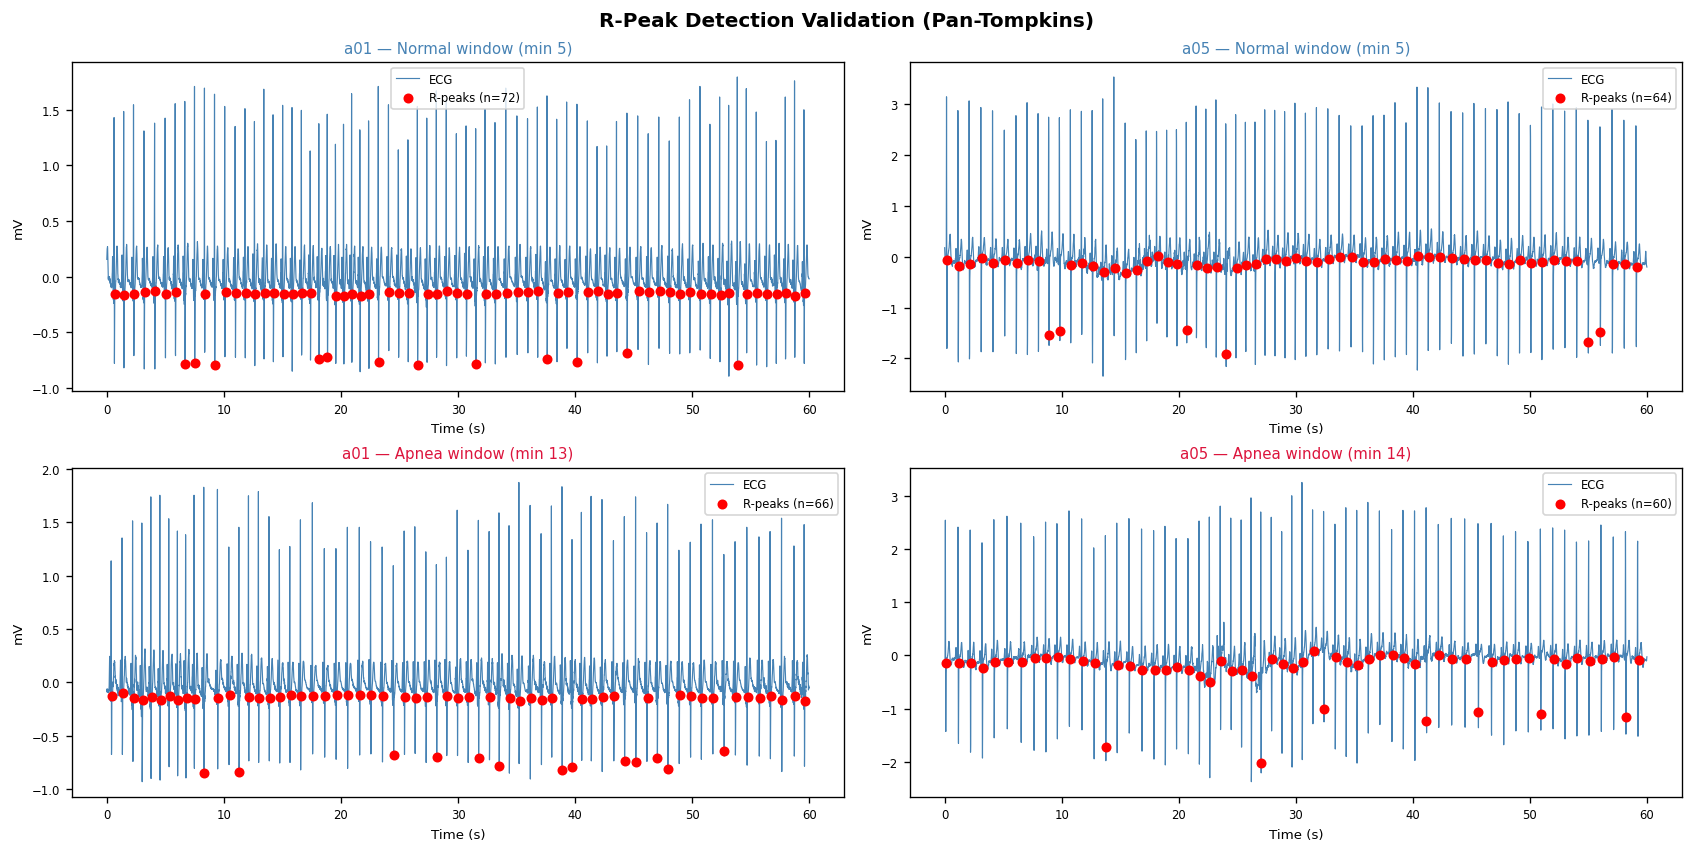

Saved: /Users/dennisray/sleepApnea/apnea-project/reports/figures/rpeak_validation.png


In [6]:
# ── Cell 6: Validation plots — normal and apnea windows for a01 and a05 ───────
VALIDATE_RECS  = ['a01', 'a05']
ROW_LABELS     = {'N': 'Normal', 'A': 'Apnea'}
LABEL_COLORS   = {'N': 'steelblue', 'A': 'crimson'}

def _first_annotated_minute(ann_dict, target_sym, min_minute=5):
    for m, sym in ann_dict.items():
        if sym == target_sym and m >= min_minute:
            return m
    return None

fig, axes = plt.subplots(2, 2, figsize=(14, 7), constrained_layout=True)
fig.suptitle('R-Peak Detection Validation (Pan-Tompkins)', fontsize=12, fontweight='bold')

for col, rec_id in enumerate(VALIDATE_RECS):
    sig, fs  = load_ecg(rec_id)
    ann_dict = load_annotations(rec_id)
    rpeaks   = np.load(RPEAKS_DIR / f'{rec_id}_rpeaks.npy')

    for row, sym in enumerate(['N', 'A']):
        min_idx = _first_annotated_minute(ann_dict, sym)
        ax      = axes[row, col]

        if min_idx is None:
            ax.text(0.5, 0.5, f'No {sym} label found', ha='center', va='center',
                    transform=ax.transAxes)
            continue

        s_i   = int(min_idx * 60 * fs)
        e_i   = min(s_i + int(60 * fs), len(sig))
        chunk = sig[s_i:e_i]
        t     = np.arange(len(chunk)) / fs

        local_peaks = rpeaks[(rpeaks >= s_i) & (rpeaks < e_i)] - s_i

        ax.plot(t, chunk, lw=0.7, color='steelblue', label='ECG')
        if len(local_peaks) > 0:
            ax.scatter(local_peaks / fs, chunk[local_peaks], color='red',
                       s=25, zorder=5, label=f'R-peaks (n={len(local_peaks)})')
        ax.set_title(f'{rec_id} — {ROW_LABELS[sym]} window (min {min_idx})',
                     color=LABEL_COLORS[sym], fontsize=9)
        ax.set_xlabel('Time (s)', fontsize=8)
        ax.set_ylabel('mV', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=7)

out = FIGURES_DIR / 'rpeak_validation.png'
fig.savefig(out, dpi=150)
plt.show()
print(f'Saved: {out.resolve()}')

In [7]:
# ── Cell 7: GO / NEEDS REVIEW / STOP decision ─────────────────────────────────
flagged_recs = qc_df.loc[qc_df['flagged'], 'record_id'].tolist()

if n_flagged == 0:
    verdict = 'GO'
    detail  = 'All 70 records passed detection QC.'
elif n_flagged <= 3:
    verdict = 'NEEDS REVIEW'
    detail  = f'Flagged records ({n_flagged}): {flagged_recs}'
else:
    verdict = 'STOP'
    detail  = (f'{n_flagged} records flagged — investigate detection pipeline '
               f'before proceeding. Records: {flagged_recs}')

print('=' * 60)
print(' R-PEAK DETECTION PIPELINE DECISION')
print('=' * 60)
print(f'  Total records processed : {len(qc_df)}')
print(f'  Flagged                 : {n_flagged}')
print(f'\n  VERDICT: {verdict}')
print(f'  {detail}')
print('=' * 60)

 R-PEAK DETECTION PIPELINE DECISION
  Total records processed : 70
  Flagged                 : 0

  VERDICT: GO
  All 70 records passed detection QC.
